<a href="https://colab.research.google.com/github/Mr-Zainulabadin/python_programing/blob/main/fcomplete_ga_ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Complete GA Feature Selection Project

In [1]:
!pip install sklearn-genetic-opt kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 11.6 MB/s eta 0:00:00


In [2]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

from sklearn.feature_selection import mutual_info_classif

from sklearn_genetic import GAFeatureSelectionCV


In [3]:
path = kagglehub.dataset_download(
    "uciml/pima-indians-diabetes-database"
)

csv_path = os.path.join(path, "diabetes.csv")

df = pd.read_csv(csv_path)

print(df.head())


Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df[cols] = df[cols].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')

df[cols] = imputer.fit_transform(df[cols])


In [5]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]


In [6]:
def calculate_metrics(model_name, y_test, y_pred, y_prob):

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    auc = roc_auc_score(y_test, y_prob)

    return {
        "Model": model_name,
        "Accuracy": round(accuracy*100,2),
        "Precision": round(precision*100,2),
        "Recall": round(recall*100,2),
        "Specificity": round(specificity*100,2),
        "F1 Score": round(f1*100,2),
        "AUC": round(auc*100,2)
    }


In [7]:
estimator = RandomForestClassifier(
    n_estimators=100,
    random_state=1
)

wrapper_selector = GAFeatureSelectionCV(
    estimator=estimator,
    cv=5,
    scoring="accuracy",
    population_size=30,
    generations=10,
    crossover_probability=0.5,
    mutation_probability=0.2,
    n_jobs=-1
)

wrapper_selector.fit(X, y)

wrapper_features = X.columns[
    wrapper_selector.support_
]

X_wrapper = X[wrapper_features]


gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	30    	0.684061	0.0395058  	0.748731   	0.618572   
1  	40    	0.704867	0.0328856  	0.753943   	0.626331   
2  	46    	0.738063	0.0157868  	0.756549   	0.68888    
3  	42    	0.750124	0.0046625  	0.756549   	0.738316   
4  	40    	0.754238	0.00309236 	0.763076   	0.747424   
5  	42    	0.755751	0.00313037 	0.766981   	0.748731   
6  	46    	0.758225	0.00426814 	0.766981   	0.753951   
7  	41    	0.761185	0.00568793 	0.766981   	0.744852   
8  	43    	0.765674	0.00286702 	0.766981   	0.757813   
9  	38    	0.767025	0.000236171	0.768296   	0.766981   
10 	34    	0.767025	0.000236171	0.768296   	0.766981   


In [8]:
mi_scores = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Score': mi_scores
})

mi_df = mi_df.sort_values(
    by='Score',
    ascending=False
)

filter_features = mi_df['Feature'].head(5)

X_filter = X[filter_features]


In [9]:
rf_embed = RandomForestClassifier(
    n_estimators=100,
    random_state=1
)

rf_embed.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_embed.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

embedded_features = importance['Feature'].head(5)

X_embedded = X[embedded_features]


In [10]:
def evaluate_single_model(model, model_name, X_selected, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X_selected,
        y,
        test_size=0.30,
        random_state=1,
        stratify=y
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)

    recall = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    auc = roc_auc_score(y_test, prob)

    return {
        'Model': model_name,
        'Accuracy': round(accuracy*100,2),
        'Precision': round(precision*100,2),
        'Recall': round(recall*100,2),
        'F1 Score': round(f1*100,2),
        'AUC': round(auc*100,2)
    }


In [11]:
all_results = []

models = {
    'Decision Tree': DecisionTreeClassifier(
        criterion='entropy',
        random_state=1
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        criterion='entropy',
        random_state=1
    ),

    'Naive Bayes': GaussianNB()
}

for model_name, model in models.items():

    result = evaluate_single_model(
        model,
        model_name,
        X_wrapper,
        y
    )

    result['GA Method'] = 'Wrapper-Based GA'

    all_results.append(result)

for model_name, model in models.items():

    result = evaluate_single_model(
        model,
        model_name,
        X_filter,
        y
    )

    result['GA Method'] = 'Filter-Based GA'

    all_results.append(result)

for model_name, model in models.items():

    result = evaluate_single_model(
        model,
        model_name,
        X_embedded,
        y
    )

    result['GA Method'] = 'Embedded GA'

    all_results.append(result)

final_results_df = pd.DataFrame(all_results)

print(final_results_df)


           Model  Accuracy  Precision  Recall  F1 Score    AUC  \
0  Decision Tree     74.03      64.38   58.02     61.04  70.35   
1  Random Forest     73.59      64.29   55.56     59.60  80.61   
2    Naive Bayes     72.73      61.54   59.26     60.38  79.02   
3  Decision Tree     74.46      64.47   60.49     62.42  71.25   
4  Random Forest     73.59      63.16   59.26     61.15  81.25   
5    Naive Bayes     73.16      63.77   54.32     58.67  78.95   
6  Decision Tree     71.86      60.26   58.02     59.12  68.68   
7  Random Forest     75.76      68.12   58.02     62.67  82.23   
8    Naive Bayes     73.16      66.10   48.15     55.71  78.81   

          GA Method  
0  Wrapper-Based GA  
1  Wrapper-Based GA  
2  Wrapper-Based GA  
3   Filter-Based GA  
4   Filter-Based GA  
5   Filter-Based GA  
6       Embedded GA  
7       Embedded GA  
8       Embedded GA  


In [12]:
best_result = final_results_df.loc[
    final_results_df['Accuracy'].idxmax()
]

print(best_result)


Model        Random Forest
Accuracy             75.76
Precision            68.12
Recall               58.02
F1 Score             62.67
AUC                  82.23
GA Method      Embedded GA
Name: 7, dtype: object


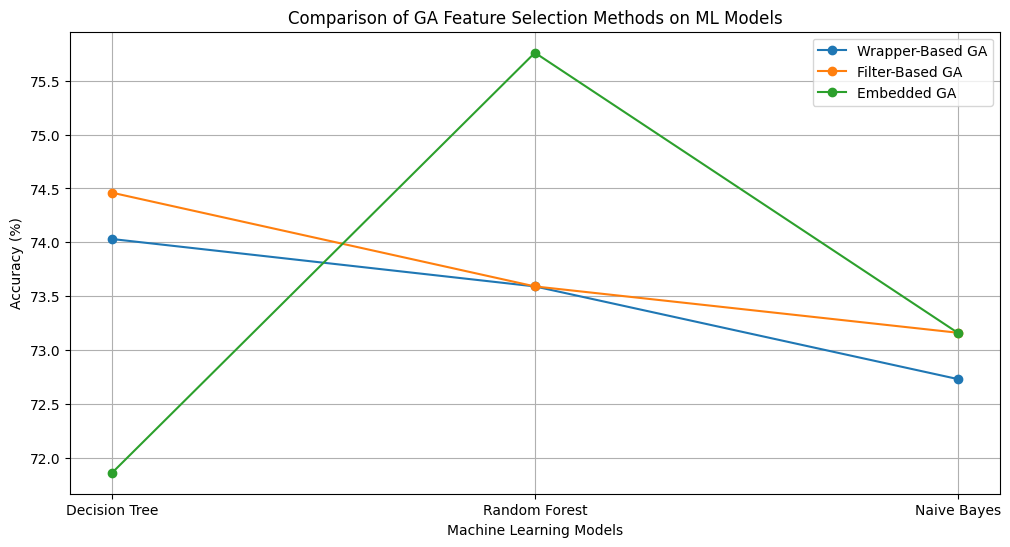

In [13]:
plt.figure(figsize=(12,6))

for method in final_results_df['GA Method'].unique():

    subset = final_results_df[
        final_results_df['GA Method'] == method
    ]

    plt.plot(
        subset['Model'],
        subset['Accuracy'],
        marker='o',
        label=method
    )

plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy (%)")

plt.title("Comparison of GA Feature Selection Methods on ML Models")

plt.legend()

plt.grid(True)

plt.show()


# Analysis

This notebook compares multiple Genetic Algorithm feature selection approaches on Decision Tree, Random Forest, and Naive Bayes classifiers.


In [14]:
# ============================================================
# FIND MOST ACCURATE MODEL
# ============================================================

best_result = final_results_df.loc[
    final_results_df['Accuracy'].idxmax()
]

print("\n")
print("="*80)
print("MOST ACCURATE MODEL AND FEATURE SELECTION METHOD")
print("="*80)

print(best_result)

print("\n")
print("Best GA Method :", best_result['GA Method'])

print("Best ML Model  :", best_result['Model'])

print("Best Accuracy  :", best_result['Accuracy'])



MOST ACCURATE MODEL AND FEATURE SELECTION METHOD
Model        Random Forest
Accuracy             75.76
Precision            68.12
Recall               58.02
F1 Score             62.67
AUC                  82.23
GA Method      Embedded GA
Name: 7, dtype: object


Best GA Method : Embedded GA
Best ML Model  : Random Forest
Best Accuracy  : 75.76
